# Introduction to Data Analysis

In this section, we import essential libraries that will help us explore and analyze the dataset.
- `pandas` for data manipulation.
- `matplotlib` & `seaborn` for data visualization.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Let's load the **120 Years of Olympic History - Athletes and Results** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [4]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

Understanding the structure of the dataset is key before diving into analysis. Let's:
- Check the data types of each column.
- Count non-null values.
- Look at the first few rows.

In [3]:
print("Dataset Overview:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None

First 5 rows:
   ID                      Name Sex   Age  Height  Weight            Team  \
0   1                 A Dijiang   M  24.0   180.0    80.0       

A quick glance at summary statistics helps us understand numerical distributions, potential outliers, and missing values.

In [4]:
print("\nSummary Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())


Summary Statistics:
                  ID            Age         Height         Weight  \
count  271116.000000  261642.000000  210945.000000  208241.000000   
mean    68248.954396      25.556898     175.338970      70.702393   
std     39022.286345       6.393561      10.518462      14.348020   
min         1.000000      10.000000     127.000000      25.000000   
25%     34643.000000      21.000000     168.000000      60.000000   
50%     68205.000000      24.000000     175.000000      70.000000   
75%    102097.250000      28.000000     183.000000      79.000000   
max    135571.000000      97.000000     226.000000     214.000000   

                Year  
count  271116.000000  
mean     1978.378480  
std        29.877632  
min      1896.000000  
25%      1960.000000  
50%      1988.000000  
75%      2002.000000  
max      2016.000000  

Missing Values:
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC           

Missing values can affect our analysis. Here, we handle missing values in the 'Height' and 'Weight' columns by filling them with the median values.

In [5]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

Grouping and counting occurrences of sports helps us understand which events are most frequent in the dataset.

In [6]:
print("\nTop 5 Most Frequent Sports:")
print(df['Sport'].value_counts().head(5))


Top 5 Most Frequent Sports:
Sport
Athletics     38624
Gymnastics    26707
Swimming      23195
Shooting      11448
Cycling       10859
Name: count, dtype: int64


A histogram is a great way to visualize the distribution of ages among Olympic athletes.

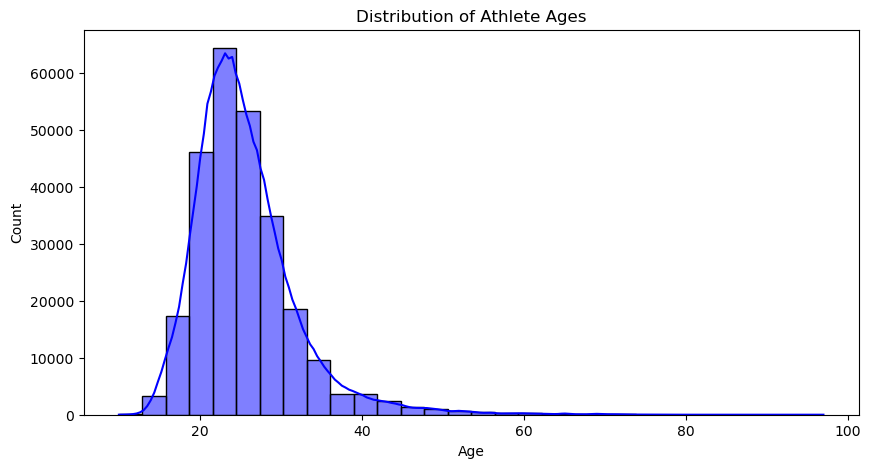

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='blue')
plt.title('Distribution of Athlete Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

By grouping the data by `Sport` and computing the mean age, we can determine the age distribution across different sports.

In [9]:
sport_ages = df.groupby('Sport')['Age'].mean().sort_values(ascending=False)
print("\nTop 5 Sports by Average Athlete Age:")
print(sport_ages.head(10))


Top 5 Sports by Average Athlete Age:
Sport
Roque               53.333333
Art Competitions    45.901009
Alpinism            38.812500
Polo                35.333333
Equestrianism       34.390831
Croquet             33.733333
Shooting            33.422226
Motorboating        33.333333
Jeu De Paume        32.454545
Curling             31.412527
Name: Age, dtype: float64


A bar chart is useful for comparing the average ages of athletes in different sports.

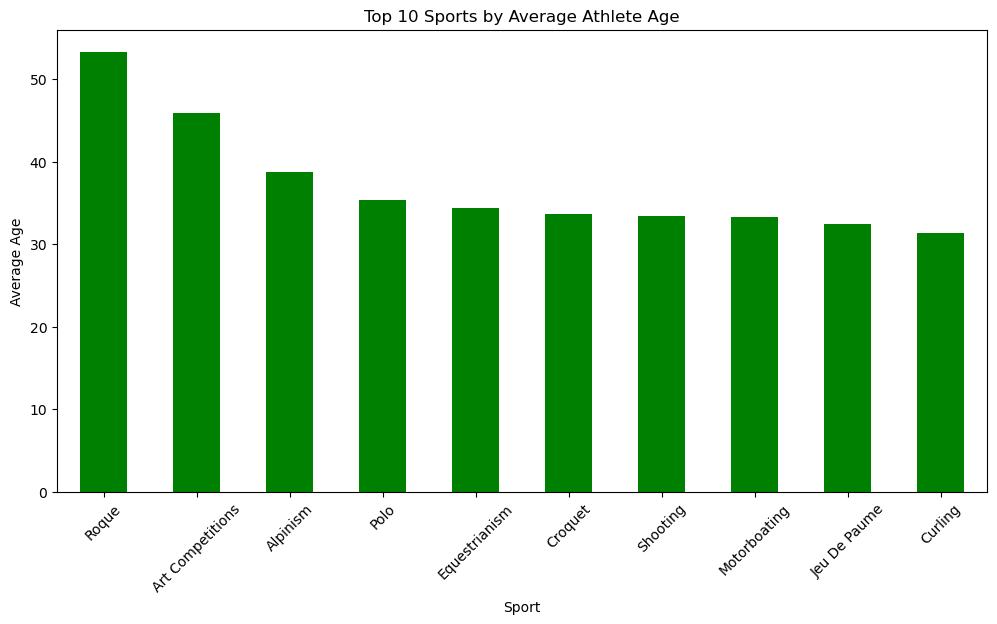

In [ ]:
plt.figure(figsize=(12,6))
sport_ages.head(30).plot(kind='bar', color='green')
plt.title('Top 10 Sports by Average Athlete Age')
plt.xlabel('Sport')
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.show()

In [ ]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [44]:
# Plot the number of medals won per year (but if in one year 4 people participated as team and won each a medal it should count as 1 medal)
#  So if 2 people won gold in 2000, it should count as 1 medal for that year, not 2.as_integer_ratio
medals_per_year = df[df['Medal'].notnull()].groupby('Year')['Medal'].nunique()
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [46]:
url = "https://raw.githubusercontent.com/cstorm125/information_value/refs/heads/master/data/120-years-of-olympic-history-athletes-and-results/athlete_events.csv"
df = pd.read_csv(url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


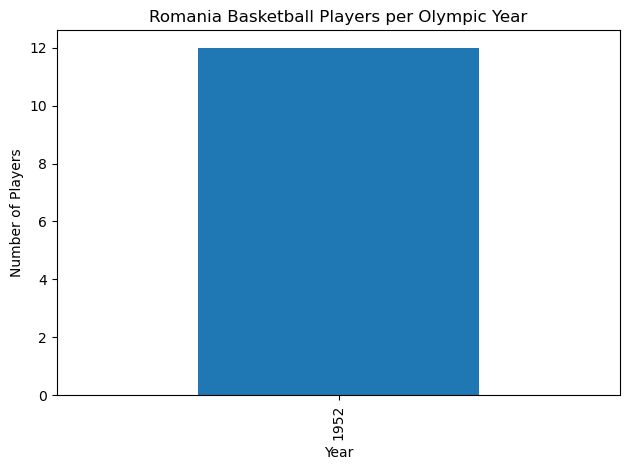

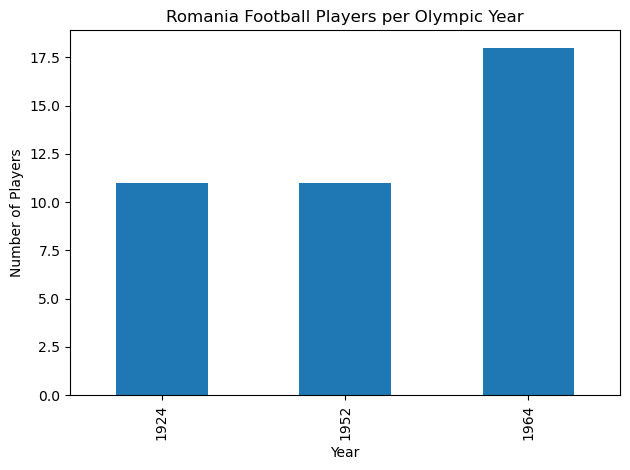

In [39]:
import matplotlib.pyplot as plt

basketball_romania = df[(df['Team'] == 'Romania') & (df['Sport'] == 'Basketball')]
basketball_romania
basketball_per_year = basketball_romania.groupby('Year')['Name'].nunique()

basketball_per_year.plot(kind='bar')
plt.title('Romania Basketball Players per Olympic Year')
plt.xlabel('Year')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()

football_romania = df[(df['Team'] == 'Romania') & (df['Sport'] == 'Football')]
football_per_year = football_romania.groupby('Year')['Name'].nunique()

football_per_year.plot(kind='bar')
plt.title('Romania Football Players per Olympic Year')
plt.xlabel('Year')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.show()


# print(df['Sport'].unique())

In [48]:

top_heighest = df.nlargest(50, 'Height')[['Name', 'Height']]
top_heighest = top_heighest.drop_duplicates(subset=['Name'])

top_heaviest = df.nlargest(50, 'Weight')[['Name', 'Weight']]
top_heaviest = top_heaviest.drop_duplicates(subset=['Name'])

top_oldest = df.nlargest(50, 'Age')[['Name', 'Age']]
top_oldest = top_oldest.drop_duplicates(subset=['Name'])

print("Top 50 Heighest Athletes:")
print(top_heighest)
print("\nTop 50 Heaviest Athletes:")
print(top_heaviest)
print("\nTop 50 Oldest Athletes:")
print(top_oldest)    

Top 50 Heighest Athletes:
                                                     Name  Height
265040                                           Yao Ming   226.0
32376                                Tommy Loren Burleson   223.0
207373                              Arvydas Romas Sabonis   223.0
17669                                      Gunther Behnke   221.0
59371                              Roberto Dueas Hernndez   221.0
269053                                       Zhang Zhaoxu   221.0
141983                         Lucien James "Luc" Longley   220.0
181241                  Viktor Aleksandrovich Pankrashkin   220.0
240656                      Volodymyr Petrovych Tkachenko   220.0
166544                     Dmitry Aleksandrovich Musersky   219.0
196667                           Peter John Ramos Fuentes   219.0
22743                                            Uwe Blab   218.0
34307                              Andrew "Andy" Campbell   218.0
87972                                    Hamed E. 

<Axes: xlabel='Year'>

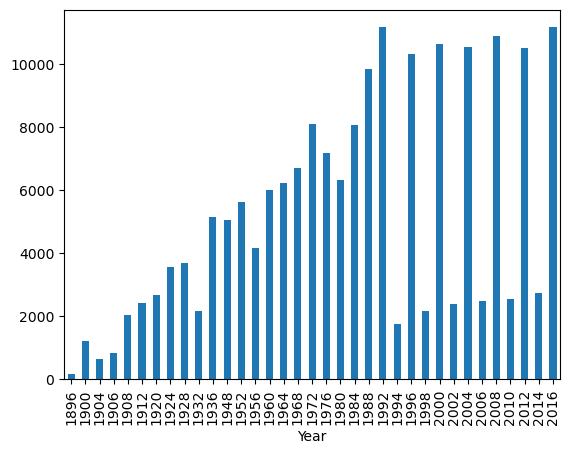

In [49]:
participant_per_year = df.groupby('Year')['Name'].nunique()
participant_per_year.plot(kind='bar')

In [51]:
name_of_sports_with_least_participants = df.groupby('Sport')['Name'].nunique().sort_values()
print(name_of_sports_with_least_participants.head(20))

Sport
Aeronautics              1
Basque Pelota            2
Roque                    4
Racquets                 7
Croquet                 10
Jeu De Paume            11
Motorboating            14
Cricket                 24
Military Ski Patrol     24
Alpinism                25
Lacrosse                60
Polo                    87
Trampolining            93
Skeleton               146
Rugby                  155
Tug-Of-War             160
Golf                   218
Rugby Sevens           299
Curling                346
Triathlon              355
Name: Name, dtype: int64


In [55]:
# How many gold medals does Lebro James have ?
lebron_gold_medals = df[(df['Name'] == 'LeBron Raymone James') & (df['Medal'] == 'Gold')]
print(f"LeBron James has won {lebron_gold_medals.shape[0]} gold")

LeBron James has won 2 gold


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [57]:
# compute whether there were more males or females
gender_counts = df['Sex'].value_counts()
print(gender_counts)

Sex
M    196594
F     74522
Name: count, dtype: int64


Text(0.5, 1.0, 'Top 10 Sports by Average Age with Age Distribution')

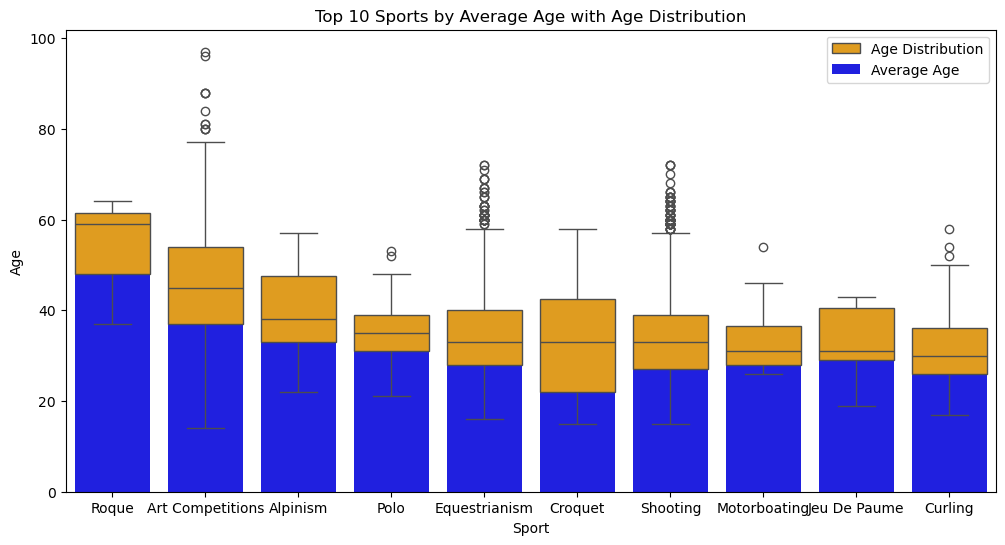

In [58]:
# Make a crazy plot with the top 10 sports by average age, but also show the distribution of ages for each sport in a boxplot on the same figure. Use different colors for the bars and the boxplots, and make sure to include a legend to differentiate between them.

top_10_sports = df.groupby('Sport')['Age'].mean().sort_values(ascending=False).head(10) 
plt.figure(figsize=(12,6))
sns.barplot(x=top_10_sports.index, y=top_10_sports.values, color='blue', label='Average Age')
sns.boxplot(x='Sport', y='Age', data=df[df['Sport'].isin(top_10_sports.index)], color='orange', label='Age Distribution')
plt.title('Top 10 Sports by Average Age with Age Distribution')
